# Model Pruning
## AIAT 122 – Deep Learning

## Learning objectives
- Understand pruning: removing small weights to reduce model size and speed.
- Apply magnitude-based pruning and compare non-zero counts and accuracy.

**Where is this used in real life?** Mobile and edge devices need smaller, faster models. **We use pruning to reduce non-zero weights** instead of only training a smaller network because we can compress an already accurate model; pruning often keeps most accuracy while cutting size.

**Prerequisites:** Basic TensorFlow/Keras. If TensorFlow import fails, see DOCS/COLAB_SETUP.md.

**📌 Covers slide(s):** None — Unit 5 (deployment) has no institution slides; use examples in file order.


## Short theory
- **Pruning** = set some weights to zero (typically the smallest by magnitude).
- **Magnitude pruning:** After training, rank weights by |w| and zero out the smallest fraction (e.g. 50%).
- **Sparsity:** Fraction of weights that are zero; higher sparsity → smaller model when stored with sparse format.
- **Trade-off:** Too much pruning can hurt accuracy; in practice we prune gradually or use pruning-aware training.

## Inputs & Outputs
**Inputs:** TensorFlow, a small Keras model, synthetic or small dataset.  
**Dataset:** Synthetic — random data (no download; used to demonstrate pruning).  
**Outputs:** Trained model, pruned model (magnitude-based), non-zero weight count and accuracy before/after, and a simple bar plot. Run time: under ~5 min (few epochs).


In [1]:
import numpy as np
import matplotlib.pyplot as plt
try:
    import tensorflow as tf
    print("TensorFlow version:", tf.__version__)
except Exception as e:
    err = str(e).lower()
    if "charset_normalizer" in err or "md__mypyc" in err or "partially initialized" in err:
        print("⚠️ Fix: pip install --upgrade charset-normalizer requests, then restart kernel.")
        raise RuntimeError("Fix: pip install --upgrade charset-normalizer requests, then restart kernel.") from e
    raise
print("✅ Imports OK.")

TensorFlow version: 2.13.0
✅ Imports OK.


### Step 1: Build and train a small model (2 epochs so it runs fast)

In [2]:
# Synthetic data for quick demo (we use 2 epochs so it runs in ~1 min)
X = np.random.randn(1000, 20).astype(np.float32)
y = (X[:, :5].sum(axis=1) > 0).astype(np.float32).reshape(-1, 1)
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation="relu", input_shape=(20,)),
    tf.keras.layers.Dense(32, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid"),
])
model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
model.fit(X, y, epochs=2, verbose=1)
loss0, acc0 = model.evaluate(X, y, verbose=0)
print(f"Before pruning: loss={loss0:.4f}, accuracy={acc0:.4f}")
n_before = sum(np.prod(w.shape) for w in model.get_weights())
print(f"Total parameters: {n_before}")

Epoch 1/2
32/32 [==============================] - 0s 395us/step - loss: 0.6362 - accuracy: 0.6690
Epoch 2/2
32/32 [==============================] - 0s 331us/step - loss: 0.4823 - accuracy: 0.8490
Before pruning: loss=0.3980, accuracy=0.9000
Total parameters: 3457


### Step 2: Magnitude pruning (zero out smallest 50% of weights)

In [3]:
# We use magnitude pruning: zero out weights with smallest |value| (simple demo; in production use tfmot)
sparsity = 0.5  # zero out 50% of weights
for layer in model.layers:
    w = layer.get_weights()
    if len(w) == 0:
        continue
    weights = w[0]
    flat = np.abs(weights.flatten())
    thresh = np.percentile(flat, sparsity * 100)
    weights[np.abs(weights) <= thresh] = 0
    layer.set_weights([weights] + (w[1:] if len(w) > 1 else []))
n_after = np.sum([np.count_nonzero(w) for w in model.get_weights()])
loss1, acc1 = model.evaluate(X, y, verbose=0)
print(f"After 50% pruning: non-zero params={n_after}, loss={loss1:.4f}, accuracy={acc1:.4f}")
print("After this cell you should see: accuracy may drop slightly; non-zero count about half of before.")

After 50% pruning: non-zero params=1777, loss=0.4725, accuracy=0.8690
After this cell you should see: accuracy may drop slightly; non-zero count about half of before.


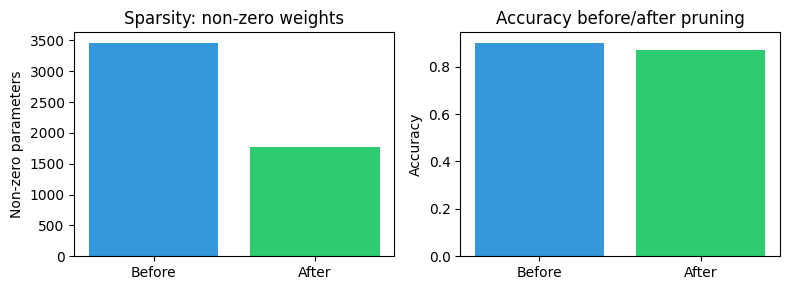

In [4]:
# Visualize: non-zero params and accuracy before vs after pruning
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(8, 3))
ax1.bar(["Before", "After"], [n_before, n_after], color=["#3498db", "#2ecc71"])
ax1.set_ylabel("Non-zero parameters")
ax1.set_title("Sparsity: non-zero weights")
ax2.bar(["Before", "After"], [acc0, acc1], color=["#3498db", "#2ecc71"])
ax2.set_ylabel("Accuracy")
ax2.set_title("Accuracy before/after pruning")
plt.tight_layout()
plt.show()

## 🧩 Mini-exercise

**Try it:** Change the pruning sparsity (e.g. 0.5 → 0.7 for 70% zeros) and run again. How do accuracy and non-zero count change?

---

## Summary
**What you did:** Built a small model, trained it, applied magnitude pruning (50% zeros), and compared non-zero parameter count and accuracy before/after with a bar chart.

**In real life you'd also:** Use TensorFlow Model Optimization (tfmot) for pruning-aware training, export to TFLite with sparse weights, and tune sparsity level.

**The main idea:** Pruning zeros out small weights to reduce size and speed; too much pruning can hurt accuracy.

**Next:** `05_model_distillation.ipynb` shows how to train a small student model to mimic a larger teacher.